In [29]:
import nextnanopy as nn
import os
import matplotlib.pyplot as plt
import numpy as np
import sys


In [30]:
path_nextnanoprojects_tools = r"C:\Users\sp6497_a\nextnanopy_projects"

In [31]:
print(sys.path)
sys.path.append(path_nextnanoprojects_tools)
print(sys.path)
from nextnano_tools.helper_functions import build_output
from nextnano_tools.simstructs import SimOut, BandStructure, Eigenstate

['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev', '', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib\\site-packages\\Pythonwin', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects', 'C:\\Users\\sp6497_a\\nextnanopy_projects']
['c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\python313.zip', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\DLLs', 'c:\\Users\\sp6497_a\\miniconda3\\envs\\nextnanodev\\Lib', 'c:\\Users\\sp6497

In [32]:
bias = r'bias_00000'
quantum_region = r'Quantum\quantum_region'

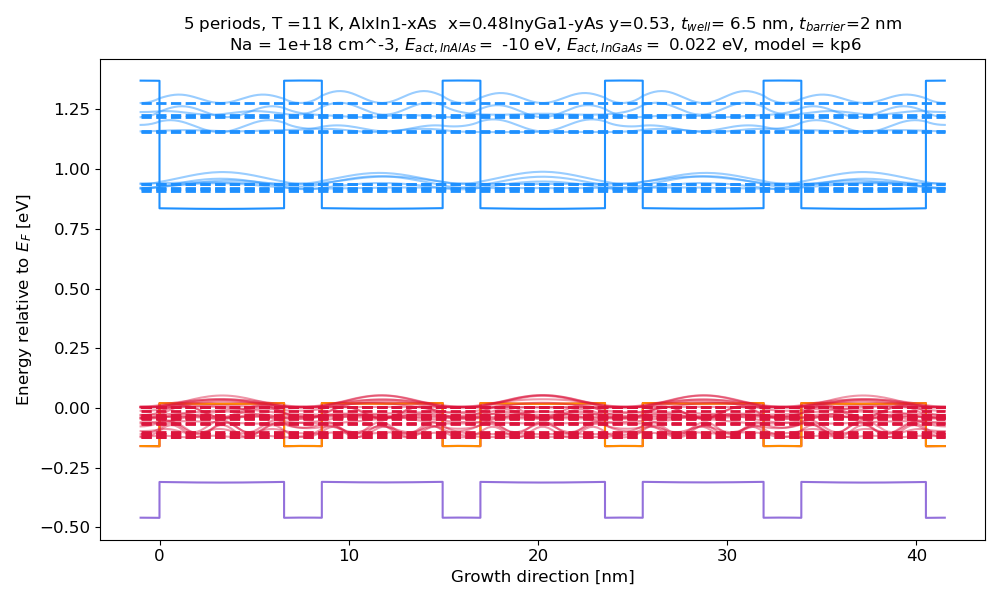

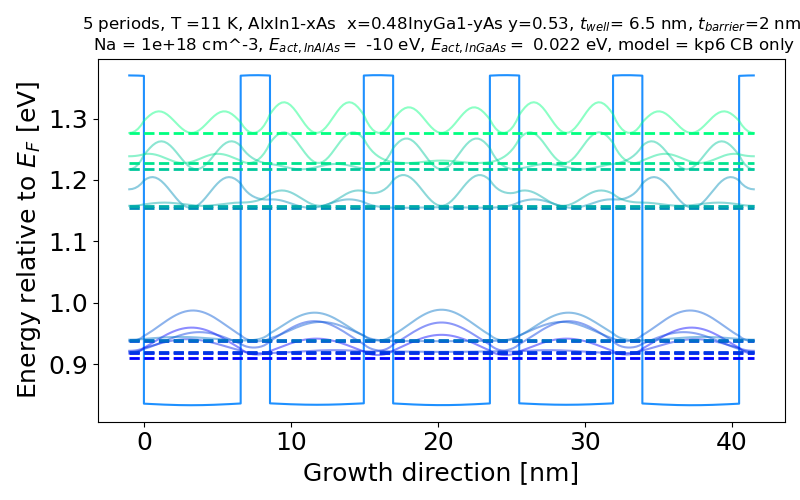

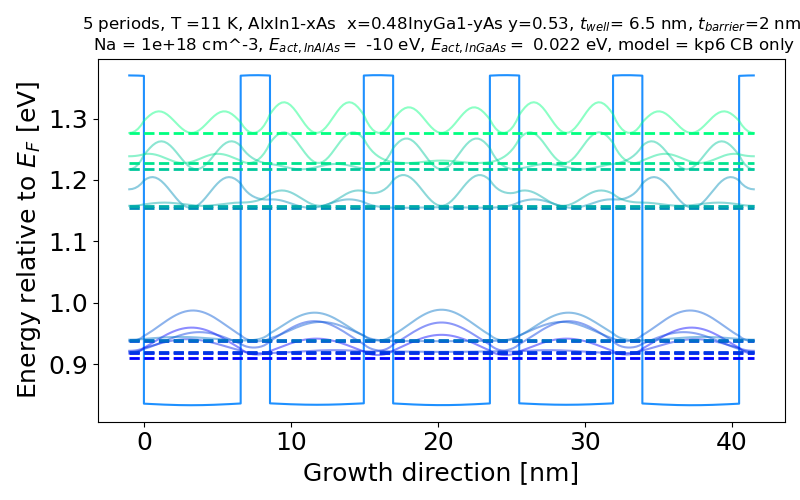

[ 0.00387587  0.00336405  0.00324185  0.00230046  0.00228506 -0.01344245
 -0.02812366 -0.02859054 -0.03782662 -0.03821156 -0.04175422 -0.04355237
 -0.04584106 -0.06478254 -0.06526524 -0.10114985 -0.10685557 -0.10945712
 -0.12144546 -0.12272593]


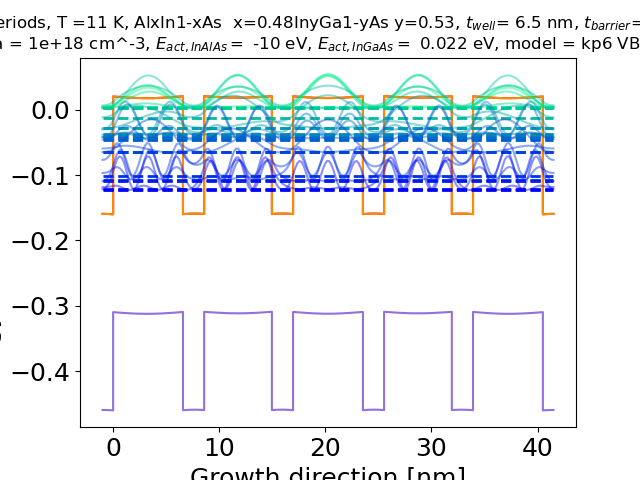

In [33]:
%matplotlib widget
parent_dir = r"C:\Users\sp6497_a\OneDrive - Princeton University\nextnano_outs\Output\miniband_InGaAs_InAlAs_bandoptions(23)"

# simoutidk = build_output(parent_dir,quantum_region,quantum_band,quantum_band_interactions,bias,14,model='kp') #multiband pass in case
model = 'kp6'
if model == 'kp6' or model == '1band':
    simout = build_output(parent_dir,quantum_region,bias,model=model)
elif model == 'kp8':
    simout = build_output(parent_dir,quantum_region,bias,model=model,VB_cutoff=-0.5)

if model == '1band':
    simout.bands['Gamma'].sort_subbands(decreasing=False)
    simout.bands['HH'].sort_subbands(decreasing=True)
    simout.bands['LH'].sort_subbands(decreasing=True)
if model == 'kp6' or model == 'kp8':
    simout.bands['CB'].sort_subbands(decreasing=False)
    simout.bands['VB'].sort_subbands(decreasing=True)

N_periods = simout.variables['N_arrayx']
temp = simout.variables['temp']
# temp = 5.0
dop_cc = simout.variables['impurity_conc_cc']
Al_x = simout.variables['Al_alloy']
In_y = simout.variables['In_alloy']
act_E_InAlAs = simout.variables['Eact_C_InAlAs']
act_E_InGaAs = simout.variables['Eact_C_InGaAs']
# Nd_GaAs_wall = simout.variables['GaAs_wall_cc']
# surrounding_cc = simout.variables['GaAs_wall_cc']
base_title = str(N_periods+1) + ' periods, T =' + str(temp) + ' K, AlxIn1-xAs  x='  + str(Al_x) + 'InyGa1-yAs y='+str(In_y)+', $t_{well}$= ' +str(simout.variables['w_well']) + ' nm, $t_{barrier}$='+ str(simout.variables['w_barrier']) + ' nm'+'\n Na = ' + str(dop_cc) + ' cm^-3, $E_{act,InAlAs}=$ ' + str(act_E_InAlAs) + ' eV, $E_{act,InGaAs}=$ ' + str(act_E_InGaAs) + ' eV, model = ' + model

simout.plot_all_bands(title_diff=base_title,fontsizebase=12,fontsizetitle=12,add_legend=False)

VB_fig,VB_ax = plt.subplots()

if model == 'kp6' or model == 'kp8':
    [fig_plot,ax_plot] = simout.bands['CB'].plot_band(title_diff=base_title + ' CB only',normalize_y=False,show_legend=False,fontsizetitle=12)
    simout.bands['VB'].plot_band(ax =VB_ax,title_diff=base_title+' VB only',normalize_y=False,show_legend=False,fontsizetitle=12)
    print(simout.bands['VB'].get_energies())
if model=='1band':
    print(simout.bands['HH'].get_energies())
    simout.bands['HH'].plot_band(ax=VB_ax,title_diff=base_title+' HH only', normalize_y=False,show=False,show_legend=False,fontsizetitle=12,fontsizebase=12)
    simout.bands['LH'].plot_band(ax=VB_ax,title_diff=base_title+' HH and LH', normalize_y=False,show=True,show_legend=False,fontsizetitle=12,fontsizebase=12)

dict_keys(['Electron_density', 'Hole_density', 'Ionized_donor_density', 'Ionized_acceptor_density', 'p-C-in-InAlAs', 'p-Si-in-InGaAs'])


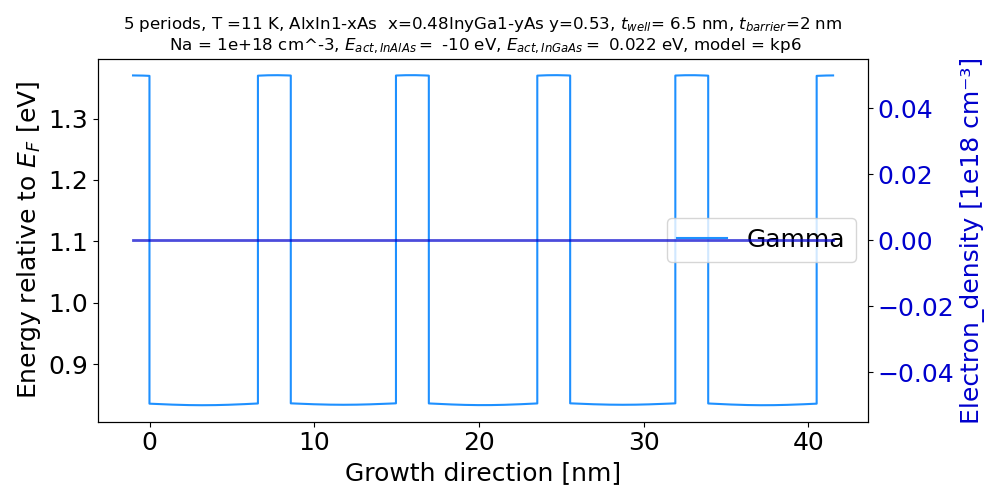

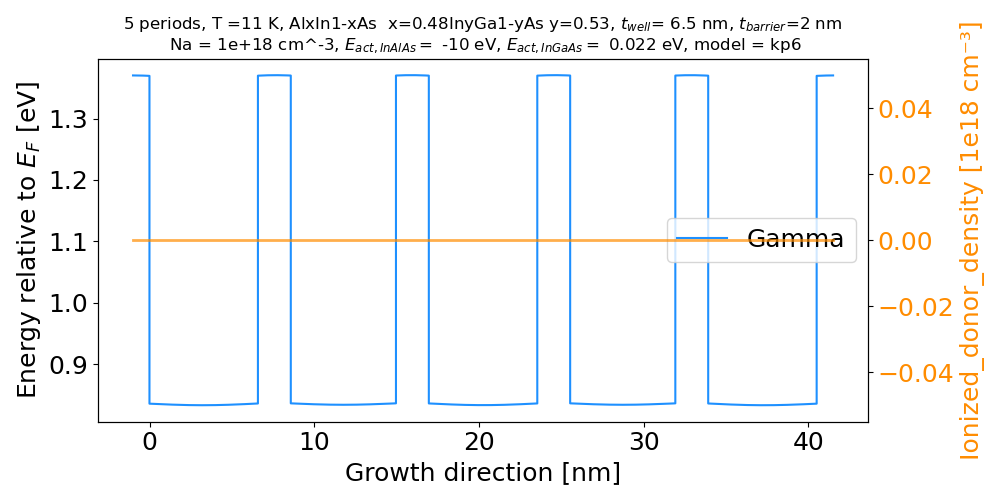

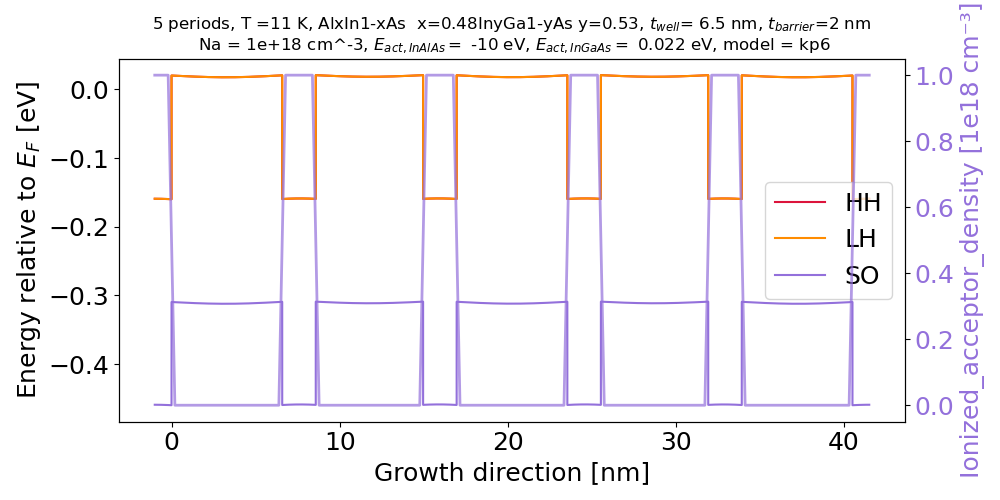

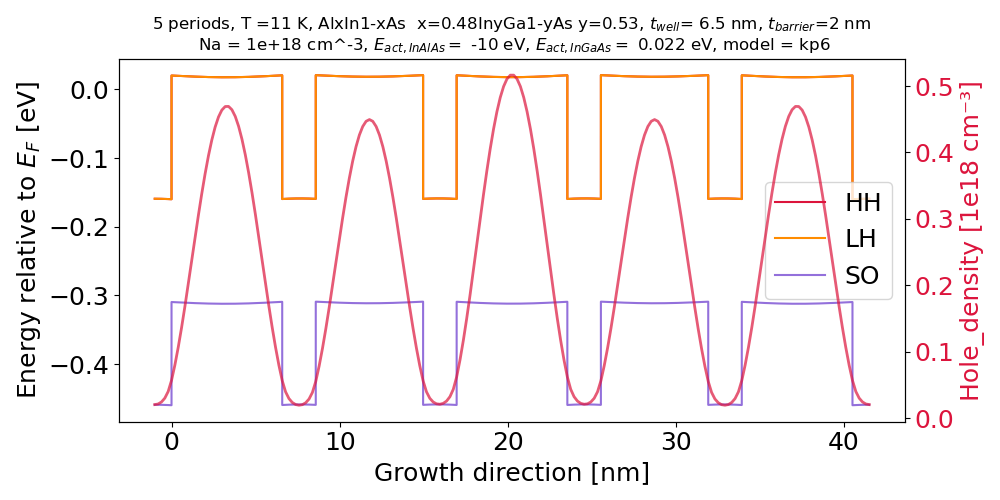

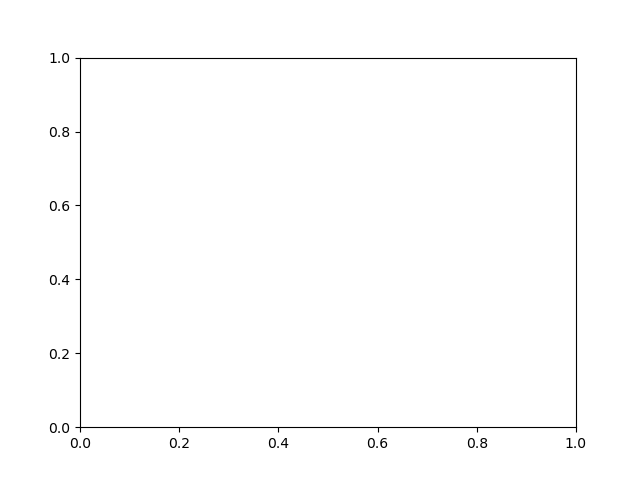

In [34]:
print(simout.densities.keys())
VB_dens_fig,VB_dens_ax = plt.subplots()
if model == 'kp6' or model == 'kp8':
    simout.plot_density('CB',density='Electron_density',title_diff=base_title,fontsizetitle=12)
    simout.plot_density('CB',density='Ionized_donor_density',title_diff=base_title ,fontsizetitle=12)
    simout.plot_density('VB',density='Ionized_acceptor_density',title_diff=base_title ,fontsizetitle=12)
    simout.plot_density('VB',density='Hole_density',title_diff=base_title,fontsizetitle=12)
if model == '1band':
    simout.plot_density('Gamma',density='Electron_density',title_diff=base_title,fontsizetitle=12)
    simout.plot_density('Gamma',density='Ionized_donor_density',title_diff=base_title ,fontsizetitle=12)
    simout.plot_density('HH',density='Ionized_acceptor_density',ax=VB_dens_ax,title_diff=base_title ,fontsizetitle=12)
    simout.plot_density('HH',density='Hole_density',ax=VB_dens_ax,title_diff=base_title,fontsizetitle=12)
# ax_carriers = simout.bands['Gamma'].bandedges[0].plot()
# ax_bandedge,ax_carriers = simout.plot_bandedge_with_density('Gamma',carrier='electron',title_diff=base_title,fontsizebase=12,fontsizetitle=14)
# simout.electron_density.plot(ax=ax_carriers)